# Deep Q-Network (DQN)

Tabular Q-Learning stores a value for every state-action pair in a lookup table.

As the number of states increases, maintaining a Q-table becomes computationally expensive and memory intensive.

A Deep Q-Network (DQN) replaces the Q-table with a neural network that approximates the Q-value function.

Instead of storing values explicitly, the network learns to predict the expected cumulative reward for each possible pricing action.

## Neural Network Architecture

Input Features:

- Remaining Inventory
- Remaining Days

Hidden Layers:

- Fully Connected Layer (64 neurons)
- ReLU Activation
- Fully Connected Layer (64 neurons)
- ReLU Activation

Output:

Five Q-values corresponding to the five pricing actions.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import torch

from src.dqn import DQN

model = DQN()

In [3]:
print(model)

DQN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [4]:
state = torch.tensor([20.0, 15.0])

output = model(state)

print(output)

tensor([ 1.8598,  2.9098, -0.6395,  3.3551, -0.3722], grad_fn=<ViewBackward0>)


In [5]:
print("Output Shape:", output.shape)

Output Shape: torch.Size([5])


In [6]:
batch = torch.tensor([[20.0, 15.0], [18.0, 10.0], [10.0, 5.0], [5.0, 2.0]])

predictions = model(batch)

print(predictions.shape)

torch.Size([4, 5])


## DQN Architecture Summary

| Component | Configuration |
|-----------|---------------|
| Input Features | 2 |
| Hidden Layer 1 | 64 neurons + ReLU |
| Hidden Layer 2 | 64 neurons + ReLU |
| Output Layer | 5 Q-values |
| Optimizer | Adam *(to be added later)* |
| Loss Function | Mean Squared Error *(to be added later)* |

# Experience Replay

Unlike Tabular Q-Learning, Deep Q-Networks do not update the neural network after every interaction.

Instead, each experience is stored in a replay memory.

A random mini-batch of experiences is later sampled from this memory for training.

Experience Replay improves learning by:

- Breaking correlations between consecutive experiences.
- Increasing sample efficiency.
- Stabilizing neural network training.

In [7]:
from src.replay_buffer import ReplayBuffer

buffer = ReplayBuffer(capacity=100)

print("Buffer Length:", len(buffer))

Buffer Length: 0


In [8]:
import numpy as np

for i in range(10):

    state = np.array([20 - i, 15 - i])

    next_state = np.array([19 - i, 14 - i])

    buffer.add(state, i % 5, 100, next_state, False)

print("Buffer Length:", len(buffer))

Buffer Length: 10


In [9]:
batch = buffer.sample(4)

print("Batch Size:", len(batch))

Batch Size: 4


In [10]:
state, action, reward, next_state, done = batch[0]

print("State:", state)
print("Action:", action)
print("Reward:", reward)
print("Next State:", next_state)
print("Done:", done)

State: [12  7]
Action: 3
Reward: 100
Next State: [11  6]
Done: False


# DQN Agent

The DQN Agent combines multiple components:

- Online Q-Network
- Target Network
- Experience Replay Buffer
- Adam Optimizer
- Mean Squared Error Loss
- Epsilon-Greedy Exploration

The target network provides stable learning by generating fixed target Q-values that are periodically synchronized with the online network.

In [11]:
from src.dqn import DQNAgent

agent = DQNAgent()

print("Device:", agent.device)
print("Batch Size:", agent.batch_size)
print("Gamma:", agent.gamma)
print("Initial Epsilon:", agent.epsilon)

Device: cpu
Batch Size: 64
Gamma: 0.95
Initial Epsilon: 1.0


In [12]:
state = [20, 15]

for _ in range(10):

    print(agent.choose_action(state))

4
0
3
4
4
1
4
0
4
1


In [13]:
policy_weights = list(agent.policy_net.parameters())[0]

target_weights = list(agent.target_net.parameters())[0]

print(torch.equal(policy_weights, target_weights))

True


## Why Use a Target Network?

During training, the policy network is updated after every optimization step.

If the same network is also used to compute target Q-values, the learning target changes continuously, making training unstable.

The target network remains fixed for several training iterations and is periodically synchronized with the policy network, resulting in more stable learning.

# Mini-Batch Learning

Unlike Tabular Q-Learning, Deep Q-Networks learn from batches of past experiences rather than a single transition.

Each optimization step consists of:

1. Sampling a random mini-batch from replay memory.
2. Predicting Q-values using the policy network.
3. Computing target Q-values using the target network.
4. Calculating the loss.
5. Updating the policy network using gradient descent.

In [14]:
agent = DQNAgent()

state, _ = agent.env.reset()

while len(agent.memory) < 100:

    action = agent.env.action_space.sample()

    next_state, reward, terminated, truncated, _ = agent.env.step(action)

    done = terminated or truncated

    agent.memory.add(state, action, reward, next_state, done)

    state = next_state

    if done:
        state, _ = agent.env.reset()

print("Replay Buffer Size:", len(agent.memory))

Replay Buffer Size: 100


In [15]:
loss = agent.train_step()

print("Training Loss:", loss)

Training Loss: 76.8658676147461


In [16]:
loss2 = agent.train_step()

print("First Loss :", loss)
print("Second Loss:", loss2)

First Loss : 76.8658676147461
Second Loss: 89.94477081298828


# Training the Deep Q-Network

During each training episode, the agent:

1. Interacts with the booking environment.
2. Stores experiences in replay memory.
3. Samples mini-batches from replay memory.
4. Updates the policy network.
5. Periodically synchronizes the target network.
6. Tracks total episode revenue and training loss.

In [17]:
agent = DQNAgent()

reward_history, loss_history = agent.train(episodes=500)

Episode 50/500 | Revenue = 1160 | Loss = 48.46 | Epsilon = 0.778
Episode 100/500 | Revenue = 1500 | Loss = 47.67 | Epsilon = 0.606
Episode 150/500 | Revenue = 1060 | Loss = 48.22 | Epsilon = 0.471
Episode 200/500 | Revenue = 920 | Loss = 42.60 | Epsilon = 0.367
Episode 250/500 | Revenue = 1380 | Loss = 44.62 | Epsilon = 0.286
Episode 300/500 | Revenue = 1520 | Loss = 39.32 | Epsilon = 0.222
Episode 350/500 | Revenue = 1120 | Loss = 44.37 | Epsilon = 0.173
Episode 400/500 | Revenue = 1520 | Loss = 43.32 | Epsilon = 0.135
Episode 450/500 | Revenue = 880 | Loss = 43.53 | Epsilon = 0.105
Episode 500/500 | Revenue = 1380 | Loss = 46.87 | Epsilon = 0.082

Best 20-Episode Average Revenue: 1259.00
Best model saved to : ..\models\best_dqn_model.pth
Final model saved to: ..\models\final_dqn_model.pth


In [18]:
import os

print(os.path.exists("../models/best_dqn_model.pth"))

True


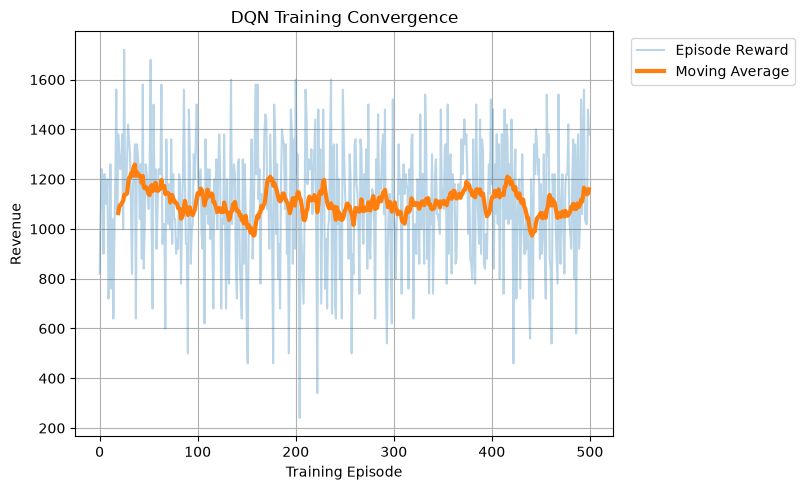

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(reward_history, alpha=0.3, label="Episode Reward")

window = 20

moving_avg = np.convolve(reward_history, np.ones(window) / window, mode="valid")

plt.plot(
    range(window - 1, len(reward_history)),
    moving_avg,
    linewidth=3,
    label="Moving Average",
)

plt.title("DQN Training Convergence")

plt.xlabel("Training Episode")

plt.ylabel("Revenue")

plt.grid(True)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig("../outputs/figures/dqn_training.png", dpi=300, bbox_inches="tight")

plt.show()

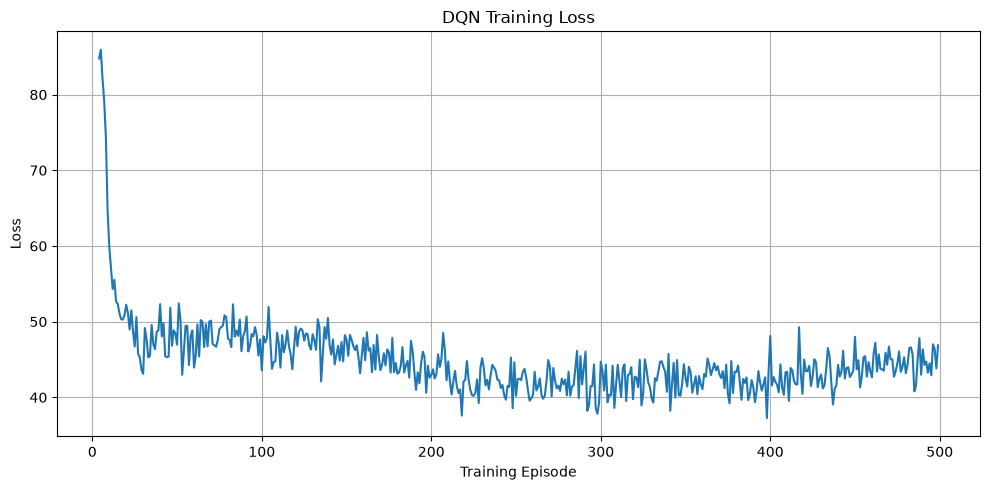

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.title("DQN Training Loss")

plt.xlabel("Training Episode")

plt.ylabel("Loss")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/dqn_loss.png", dpi=300, bbox_inches="tight")

plt.show()

## Soft Target Network Updates

Instead of periodically copying the policy network weights to the target network, this implementation applies **Polyak Averaging (Soft Updates)**.

At every training episode, the target network parameters are updated as:

Target ← τ × Policy + (1 − τ) × Target

where τ = 0.005.

This gradual synchronization produces smoother target values and often results in more stable learning.

## Huber Loss

The DQN implementation uses **Huber Loss (Smooth L1 Loss)** instead of Mean Squared Error.

Huber Loss combines the advantages of Mean Squared Error and Mean Absolute Error.

- For small prediction errors, it behaves like Mean Squared Error.
- For large prediction errors, it behaves like Mean Absolute Error.

This makes the training process less sensitive to large temporal-difference errors and generally improves the stability of Deep Q-Networks.

## Gradient Clipping

During backpropagation, very large gradients can occasionally destabilize neural network training.

To improve numerical stability, gradient clipping is applied after computing the gradients and before the optimizer updates the network parameters.

The gradient norm is clipped to a maximum value of **1.0**, preventing excessively large parameter updates while preserving the overall learning direction.